In [8]:
# Import the libraries 
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import joblib
import json

In [9]:
# Load the dataset 
df = pd.read_csv('../data/life_expectancy_data_processed.csv')

# First few rows
df.head()

,Unnamed: 0,income_comp_sq,log_hiv_aids,schooling_sq,adult_mortality,bmi_sq,mortality_per_bmi,mortality_hiv_inter,status,life_expectancy
0,0,-1.483151,-0.543192,-1.672243,1.256960,-1.165764,1.093530,-0.230435,0,54.8
1,1,-1.477007,-0.543192,-1.611430,1.216726,-1.158980,1.018874,-0.230631,0,55.3
2,2,-1.473922,-0.543192,-1.563020,-1.301966,-1.151977,-0.568216,-0.242920,0,56.2
3,3,-1.370411,-0.543192,-1.512209,1.047740,-1.144755,0.829343,-0.231456,0,56.7
4,4,-1.343083,-0.543192,-1.458998,1.031646,-1.137315,0.781856,-0.231534,0,57.0


In [10]:
# Drop the first unnecessary column
df.drop(columns = ['Unnamed: 0'], inplace = True)

df.head()

,income_comp_sq,log_hiv_aids,schooling_sq,adult_mortality,bmi_sq,mortality_per_bmi,mortality_hiv_inter,status,life_expectancy
0,-1.483151,-0.543192,-1.672243,1.256960,-1.165764,1.093530,-0.230435,0,54.8
1,-1.477007,-0.543192,-1.611430,1.216726,-1.158980,1.018874,-0.230631,0,55.3
2,-1.473922,-0.543192,-1.563020,-1.301966,-1.151977,-0.568216,-0.242920,0,56.2
3,-1.370411,-0.543192,-1.512209,1.047740,-1.144755,0.829343,-0.231456,0,56.7
4,-1.343083,-0.543192,-1.458998,1.031646,-1.137315,0.781856,-0.231534,0,57.0


In [11]:
# Separate X and y
y = df['life_expectancy']
X = df.drop(columns = ['life_expectancy'])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [12]:
# Dummy model 
dummy = DummyRegressor(strategy = 'mean')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

In [13]:
# Linear model
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [14]:
# Evaluate both models
def evaluate_model(name, y_true, y_pred):
    '''
    This function takes the name of the model, real values, and the predicted values
    to do evaluation on it and prints the result.
    '''
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f'{name} performance:')
    print(f'    RMSE: {rmse:.3f}')
    print(f'    MAE: {mae:.3f}')
    print(f'    R2: {r2:.3f}')
    print()

In [15]:
evaluate_model('Dummy Regressor', y_test, y_pred_dummy)
evaluate_model('Linear Regressor', y_test, y_pred_lr)

Dummy Regressor performance:
    RMSE: 9.453
    MAE: 7.767
    R2: -0.004

Linear Regressor performance:
    RMSE: 3.627
    MAE: 2.690
    R2: 0.852



In [16]:
# Check for overfitting of the linear regression model
y_train_pred = lr.predict(X_train)
evaluate_model('Linear Regression (TRAIN)', y_train, y_train_pred)

Linear Regression (TRAIN) performance:
    RMSE: 3.718
    MAE: 2.742
    R2: 0.848



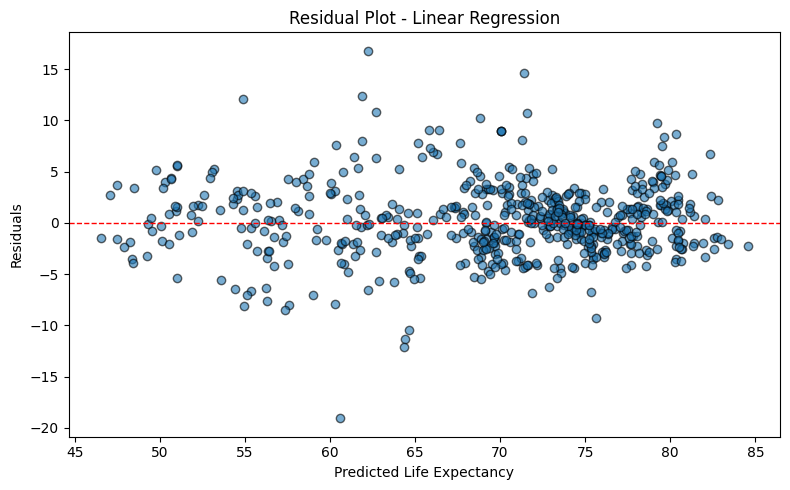

In [17]:
# Plot the residuals
residuals = y_test - y_pred_lr

plt.figure(figsize = (8, 5))
plt.scatter(y_pred_lr, residuals, alpha = 0.6, edgecolors = 'k')
plt.axhline(y = 0, color = 'r', linestyle = '--', linewidth = 1)
plt.xlabel('Predicted Life Expectancy')
plt.ylabel('Residuals')
plt.title('Residual Plot - Linear Regression')
plt.tight_layout()
plt.show()

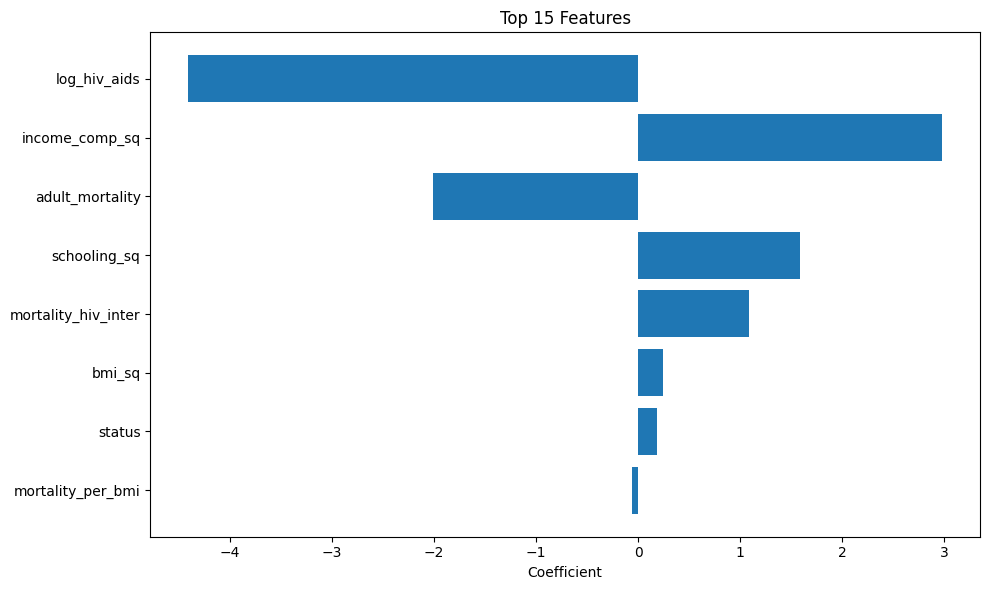

In [18]:
# Feature importance 
coefs = lr.coef_
features = X.columns

# Create a dataframe and sort by absolute importance 
coef_df = pd.DataFrame({'Feature': features, 'Coefficient': coefs})
coef_df['AbsCoefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('AbsCoefficient', ascending = False)

# Display tops
coef_df[['Feature', 'Coefficient']].head()

# Plot the coefs
plt.figure(figsize = (10, 6))
top_n = 15
plt.barh(coef_df['Feature'].head(top_n)[::-1], coef_df['Coefficient'].head(top_n)[::-1])
plt.xlabel('Coefficient')
plt.title(f'Top {top_n} Features')
plt.tight_layout()
plt.show()

In [19]:
# Params for Ridge and Lasso
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100]}

lasso_params = {'alpha': [0.001, 0.01, 0.1, 1, 10]}

In [20]:
# Ridge GridSearch
ridge_cv = GridSearchCV(
    Ridge(random_state = 42),
    ridge_params,
    cv = 5,
    scoring = 'neg_mean_squared_error',
    n_jobs = -1,
    verbose = 1
)

ridge_cv.fit(X_train, y_train)

print('Best alpha:', ridge_cv.best_params_['alpha'])
print('Best CV score:', ridge_cv.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best alpha: 10
Best CV score: -13.961923344145074


In [21]:
lasso_cv = GridSearchCV(
    Lasso(max_iter = 10000, random_state = 42),
    lasso_params,
    cv = 5,
    scoring = 'neg_mean_squared_error',
    n_jobs = -1,
    verbose = 1
)

lasso_cv.fit(X_train, y_train)

print('Best alpha:', lasso_cv.best_params_['alpha'])
print('Best CV score:', lasso_cv.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best alpha: 0.01
Best CV score: -13.954369226187499


In [22]:
# Evaluate 
y_pred_ridge = ridge_cv.predict(X_test)
y_pred_lasso = lasso_cv.predict(X_test)

evaluate_model('Ridge Model', y_test, y_pred_ridge)
evaluate_model('Lass Model', y_test, y_pred_lasso)

Ridge Model performance:
    RMSE: 3.628
    MAE: 2.690
    R2: 0.852

Lass Model performance:
    RMSE: 3.631
    MAE: 2.691
    R2: 0.852



Ridge and Lasso model did not improve our score, so we are going to use RandomForest and XGB regressors.

In [23]:
# Random Forest
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_leaf': [1, 3]
}

rf = RandomForestRegressor(random_state = 42, n_jobs = -1)

rf_cv = GridSearchCV(
    rf, rf_params,
    cv = 5,
    scoring = 'neg_mean_squared_error',
    n_jobs = -1,
    verbose = 1
)

rf_cv.fit(X_train, y_train)

print('RF Best Params:', rf_cv.best_params_)
print('RF Best Score:', rf_cv.best_score_)

# Evaluate 
y_pred_rf = rf_cv.predict(X_test)
evaluate_model('Random Forest', y_test, y_pred_rf)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
RF Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 100}
RF Best Score: -4.204484209365259
Random Forest performance:
    RMSE: 1.929
    MAE: 1.196
    R2: 0.958



In [24]:
# XGB
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

xgb = XGBRegressor(random_state = 42, n_jobs = -1)

xgb_cv = GridSearchCV(
    xgb, xgb_params,
    cv = 5,
    scoring = 'neg_mean_squared_error',
    n_jobs = -1,
    verbose = 1
)

xgb_cv.fit(X_train, y_train)

print('XGB best params:', xgb_cv.best_params_)
print('XGB best score:', xgb_cv.best_score_)

# Evaluate 
y_pred_xgb = xgb_cv.predict(X_test)
evaluate_model('XGB Model', y_test, y_pred_xgb)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
XGB best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
XGB best score: -4.5010170868764705
XGB Model performance:
    RMSE: 2.003
    MAE: 1.268
    R2: 0.955



In [25]:
# Save RandomForest model as our best model
# Commented to avoid repetitions
#joblib.dump(rf_cv.best_estimator_, '../src/random_forest_model.pkl')

#with open('../src//model/feature_names.json', 'w') as f:
    #json.dump(list(X.columns), f)